**DATASET LOADING**

In [1]:
pip install kagglehub


  Attempting uninstall: kagglesdk

    Found existing installation: kagglesdk 0.1.21

    Uninstalling kagglesdk-0.1.21:

      Successfully uninstalled kagglesdk-0.1.21

   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import kagglehub
import shutil
import os

path = kagglehub.dataset_download("madhuraatmarambhagat/crop-recommendation-dataset")

# Move to current working directory
for file in os.listdir(path):
    shutil.copy(os.path.join(path, file), os.path.join(os.getcwd(), file))

print("Files copied to:", os.getcwd())

100%|██████████| 63.7k/63.7k [00:00<00:00, 152kB/s]

Extracting files...
Files copied to: c:\Users\BAINTY KAUR\OneDrive\Desktop\Crop-Recomendation-system-using-ML\Crop-Recommendation-System-using-ML


**EDA ANALYSIS**

In [3]:
import pandas as pd

df = pd.read_csv("Crop_recommendation.csv")

print(df.shape)
print(df.head())
print(df.info())
print(df.describe())
print(df['label'].value_counts())
print(df.isnull().sum())

(2200, 8)
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 153.0 KB
None
              

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Crop_recommendation.csv")

features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

print("Ready!")

Ready!


FEATURE DISTRIBUTION

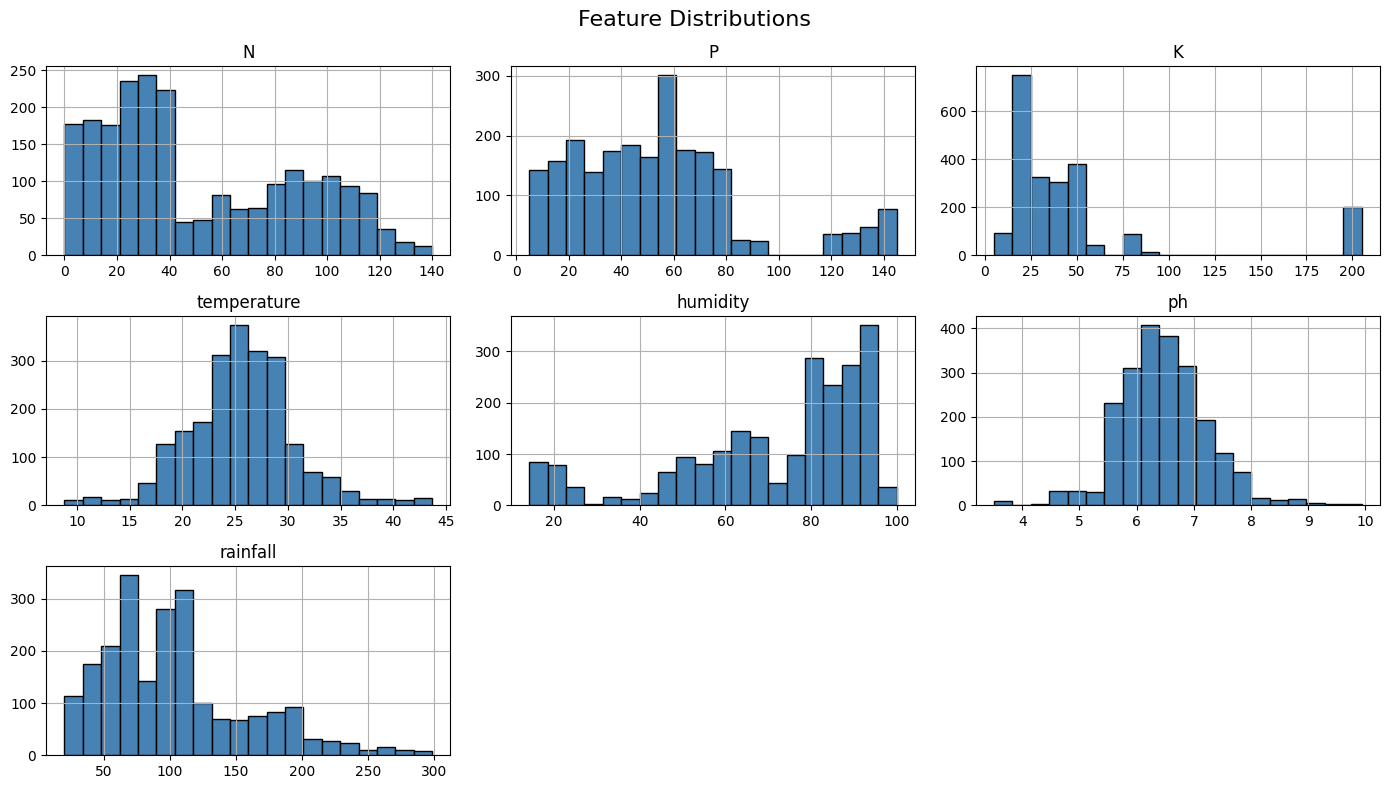

In [5]:
df[features].hist(bins=20, figsize=(14, 8), color='steelblue', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=16)
plt.tight_layout()
plt.savefig('feature_distributions.png')
plt.show()

HEATMAPS AND No. OF SAMPLES PER CROP

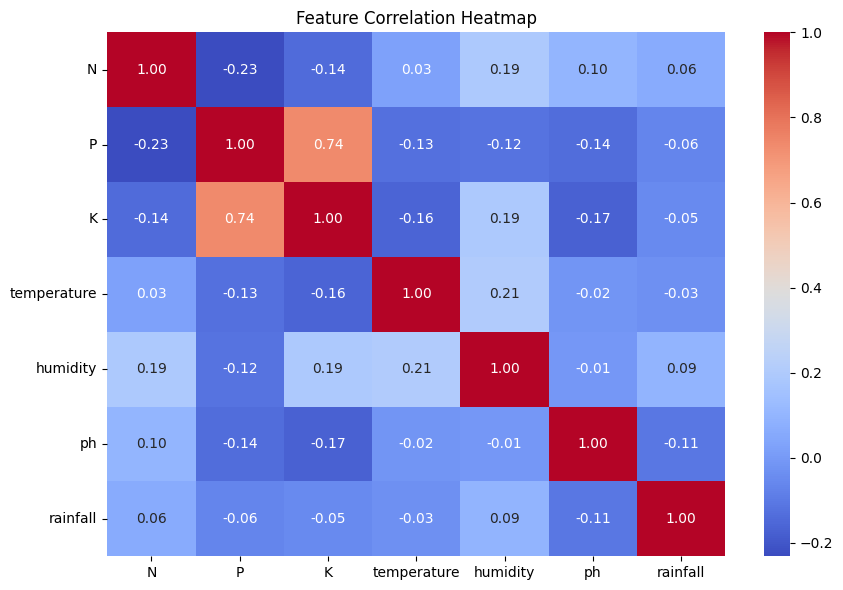

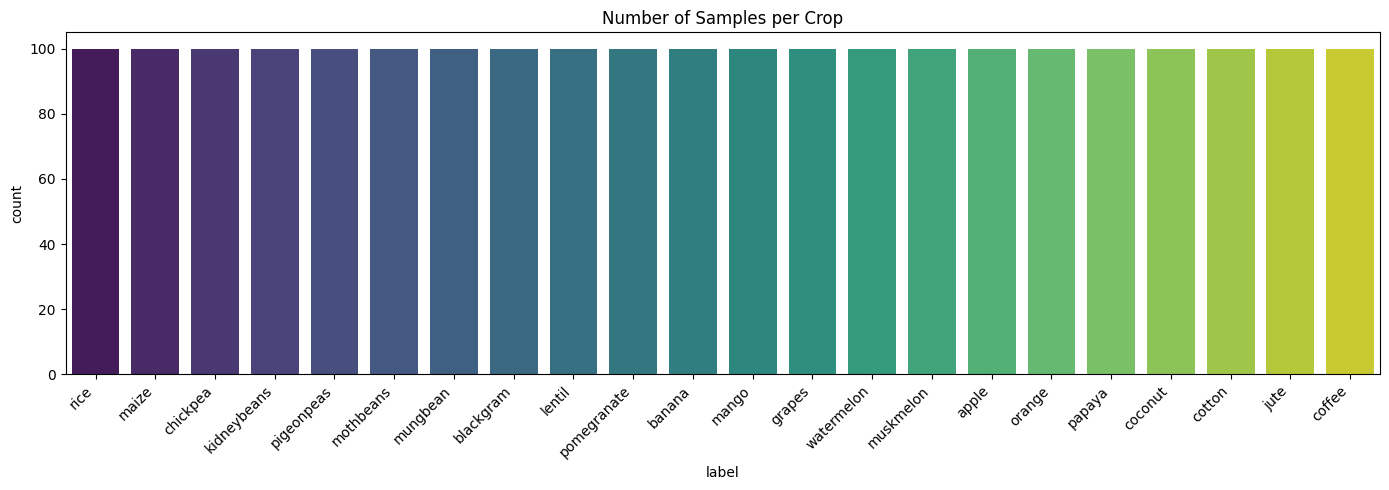

In [6]:
plt.figure(figsize=(9, 6))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

plt.figure(figsize=(14, 5))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index, 
              hue='label', palette='viridis', legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Number of Samples per Crop')
plt.tight_layout()
plt.savefig('crop_distribution.png')
plt.show()

BOXPLOTS PER CROP

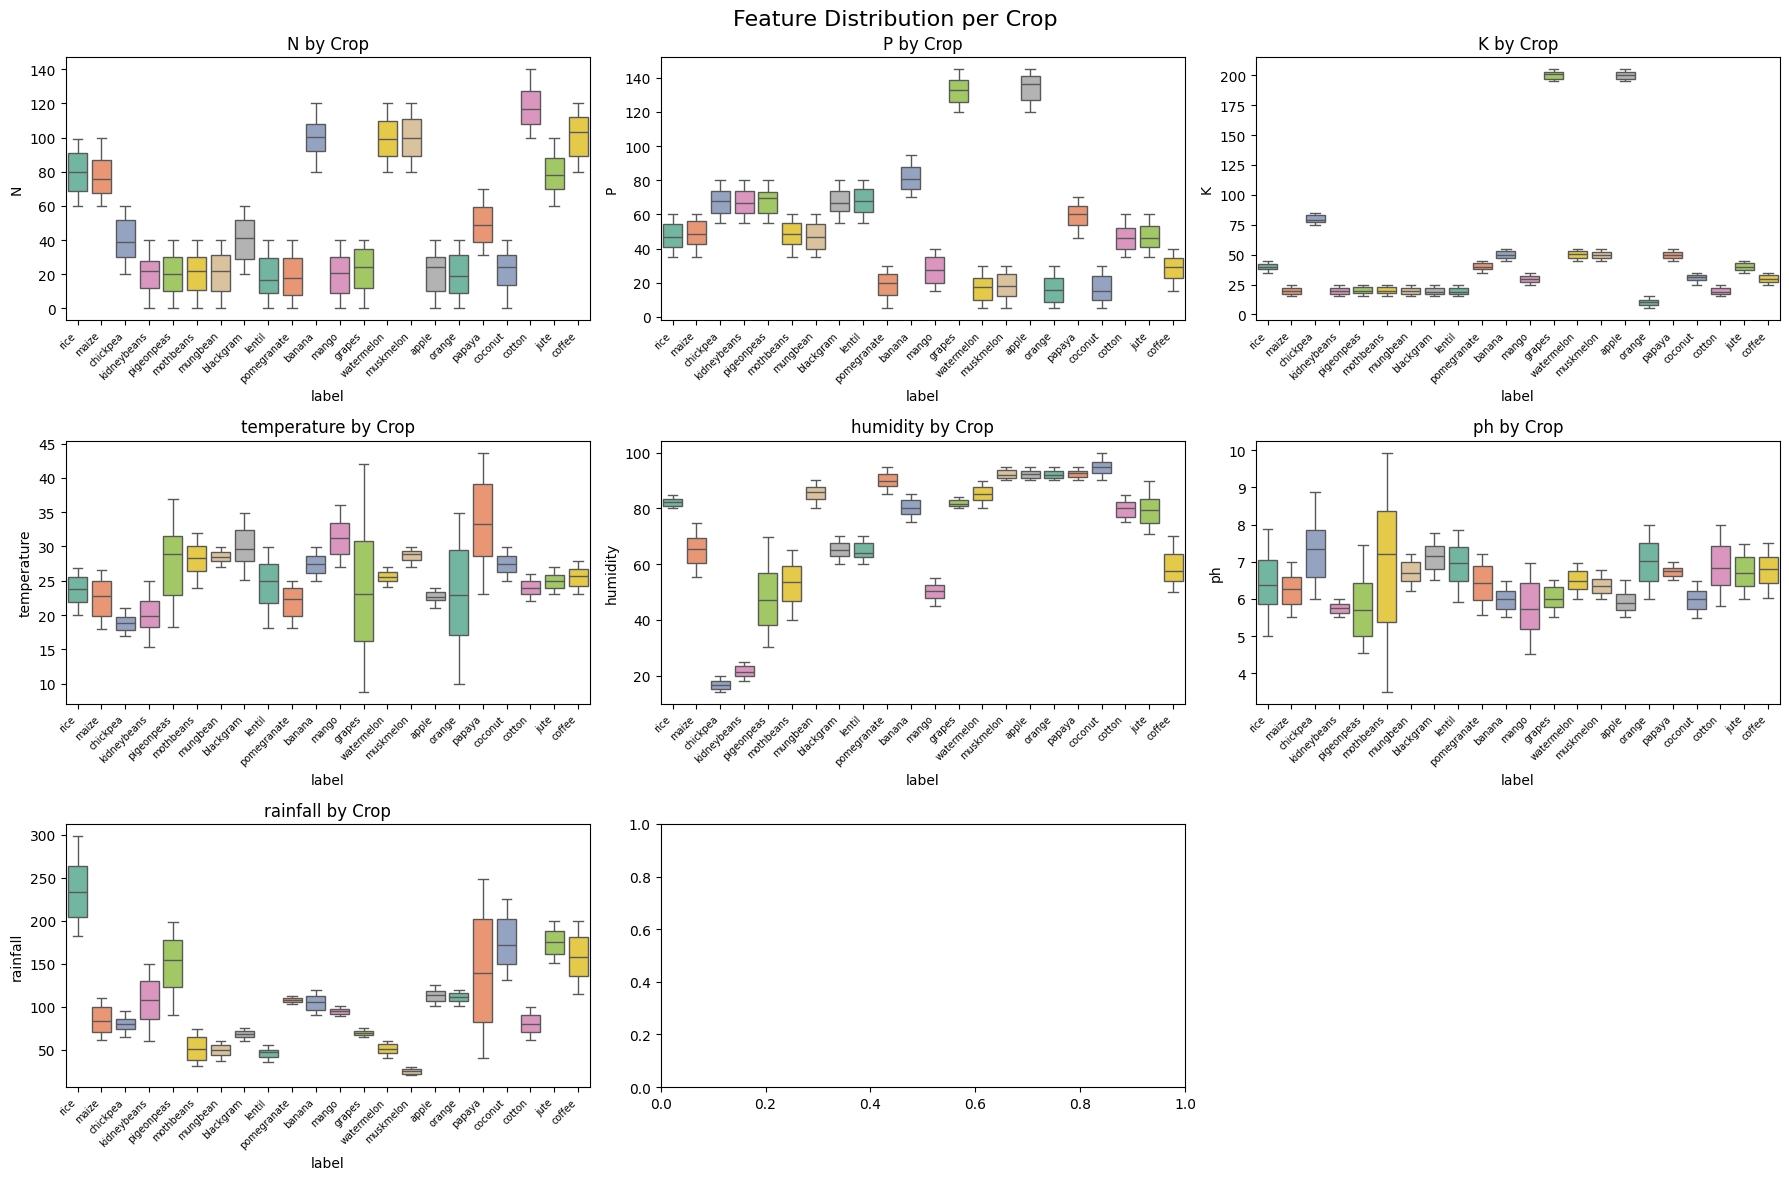

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=df, x='label', y=feature, ax=axes[i], hue='label', palette='Set2', legend=False)
    axes[i].set_title(f'{feature} by Crop')
    axes[i].tick_params(axis='x', rotation=45)
    for label in axes[i].get_xticklabels():
        label.set_fontsize(7)
        label.set_ha('right')

axes[-1].set_visible(False)
plt.suptitle('Feature Distribution per Crop', fontsize=16)
plt.tight_layout()
plt.savefig('boxplots_per_crop.png')
plt.show()

PAIR PLOTS

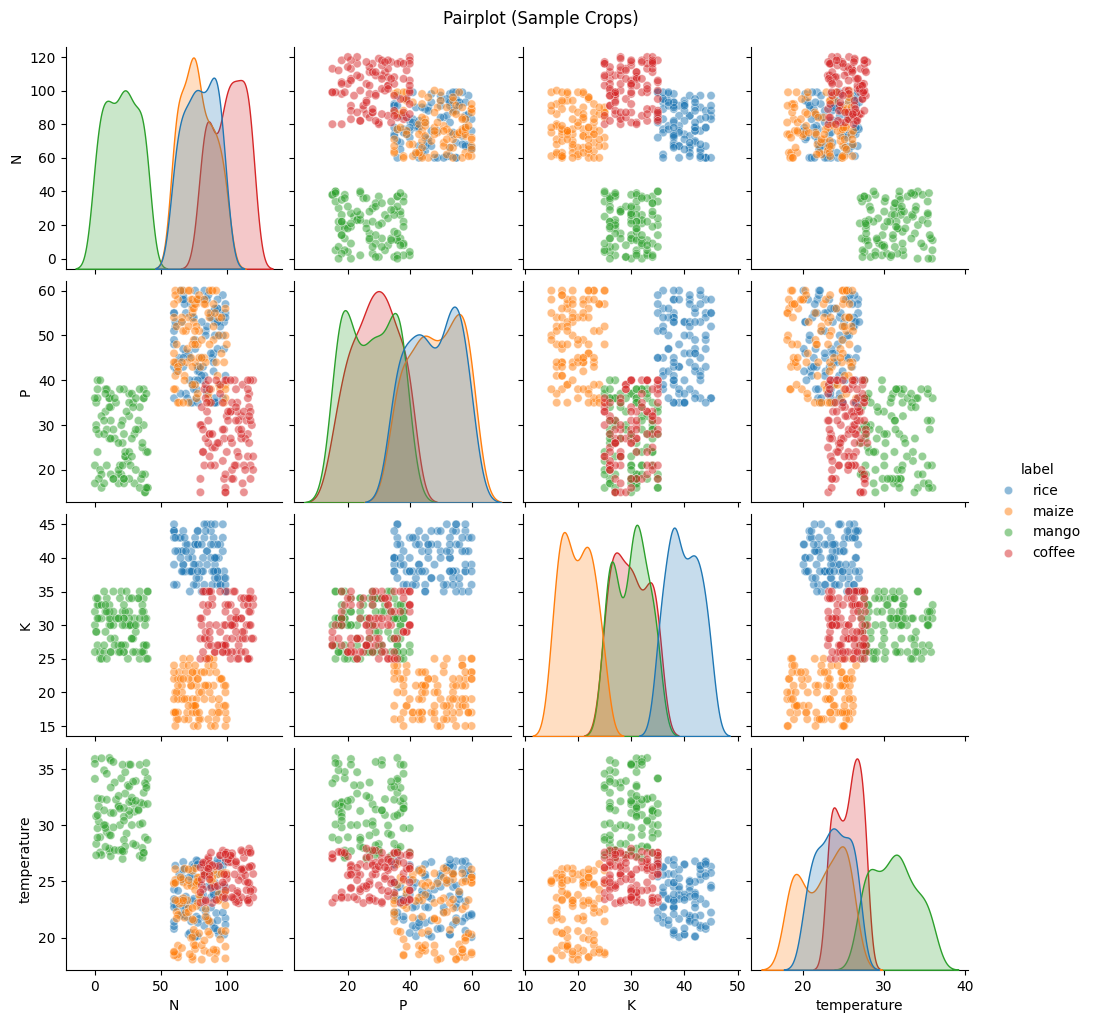

In [8]:
sample_crops = ['rice', 'maize', 'wheat', 'mango', 'coffee']
df_sample = df[df['label'].isin(sample_crops)]

sns.pairplot(df_sample, hue='label', vars=features[:4], plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot (Sample Crops)', y=1.02)
plt.savefig('pairplot.png')
plt.show()

FOLDER FOR EDA

In [9]:
import os
import shutil

# Create EDA folder
os.makedirs('EDA', exist_ok=True)

# Move all EDA images into it
eda_files = [
    'feature_distributions.png',
    'correlation_heatmap.png',
    'crop_distribution.png',
    'boxplots_per_crop.png',
    'pairplot.png'
]

for file in eda_files:
    shutil.move(file, os.path.join('EDA', file))

print("All EDA images moved to /EDA folder!")

All EDA images moved to /EDA folder!
